Let's plot up some summary plots for each tier of the scheduler

* RA,dec distribution
* alt,az distribution
* hourglass

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import healpy as hp

import rubin_sim.maf as maf
import rubin_sim.utils as rsUtils
from rubin_sim.data import get_baseline
import rubin_sim.maf.plots as plots


In [3]:
# Grab the current baseline file. Should have been downloaded with rubin_sim. 
# Can grab lots of different sims from: http://astro-lsst-01.astro.washington.edu:8081/
baseline_file = "baseline_v5.1.0_10yrs.db" #get_baseline()
name = os.path.basename(baseline_file).replace('.db','')
out_dir = 'tiers'
results_db = maf.db.ResultsDb(out_dir=out_dir)
v = " (" + name.replace('baseline_', '').split('_')[0] + ")"

In [4]:
bundle_list = []
subset_plots = [plots.HealpixSkyMap()]
notes = {"'DD:%'": {'title': "DDFs" + v}, "'pair_33%'": {'title': "33 Min Pairs" + v},
         "'templates%'": {'title': "Templates" + v},
         "'pair_15%'": {"title": "15 Min Pairs" + v}, "'greedy%'": {"title": "Greedy" + v},
         "'ToO%'": {"title": 'ToO' + v}, "'twilight%'": {"title": "Twilight Earth-Interior" + v},
         "'blob_long%'": {"title": "Hours Timescale, Initial" + v}, "'long%'": {"title": "Hours Timescale, Final" + v},
        "": {"title": "All"}}

for note in notes:
    # col here could be anything
    metric = maf.metrics.CountMetric(col=['night'], metric_name='Nvis')
    # Select all the visits. Could do something like 'filter="r"' 
    sql = 'scheduler_note like %s ' % note
    if note == "":
        sql = "night > -1 "
    slicer = maf.slicers.HealpixSlicer()
    plot_dict = notes[note]
    bundle_list.append(maf.MetricBundle(metric, slicer, sql, run_name=name, plot_dict=plot_dict, plot_funcs=subset_plots))


    slicer = maf.slicers.HealpixSlicer(
        lat_col="altitude",
        lon_col="azimuth",
        lat_lon_deg=True,
        use_cache=False,
    )
    metric = maf.metrics.CountMetric("night", metric_name="Nvisits as function of Alt/Az")
    plot_funcs = [plots.LambertSkyMap()]
    plot_dict = notes[note]
    bundle_list.append(maf.MetricBundle(metric, slicer, sql, run_name=name, plot_dict=plot_dict, plot_funcs=plot_funcs))

    slicer = maf.slicers.HourglassSlicer()
    metric = maf.metrics.HourglassMetric(
            night_col="night", metric_name="Hourglass"
        )
    bundle = maf.MetricBundle(
            metric,
            slicer,
            sql + "and night < 730",
        plot_dict=plot_dict
        )

    bundle_list.append(bundle)
    
    if note == "'ToO%'":
        metric = maf.metrics.HourglassMetric(
            night_col="night", metric_name="Hourglass, years 3-5"
        )
        plot_dict = notes[note]
        plot_dict['title'] = "ToO, years 3-5" + v
        bundle = maf.MetricBundle(
            metric,
            slicer,
            sql + "and night > 1095 and night < 1825",
        plot_dict=plot_dict
        )
        bundle_list.append(bundle)


Healpix slicer using NSIDE=128, approximate resolution 27.483891 arcminutes
Healpix slicer using NSIDE=128, approximate resolution 27.483891 arcminutes
Healpix slicer using NSIDE=128, approximate resolution 27.483891 arcminutes
Healpix slicer using NSIDE=128, approximate resolution 27.483891 arcminutes
Healpix slicer using NSIDE=128, approximate resolution 27.483891 arcminutes
Healpix slicer using NSIDE=128, approximate resolution 27.483891 arcminutes
Healpix slicer using NSIDE=128, approximate resolution 27.483891 arcminutes
Healpix slicer using NSIDE=128, approximate resolution 27.483891 arcminutes
Healpix slicer using NSIDE=128, approximate resolution 27.483891 arcminutes
Healpix slicer using NSIDE=128, approximate resolution 27.483891 arcminutes
Healpix slicer using NSIDE=128, approximate resolution 27.483891 arcminutes
Healpix slicer using NSIDE=128, approximate resolution 27.483891 arcminutes
Healpix slicer using NSIDE=128, approximate resolution 27.483891 arcminutes
Healpix slic

/Users/yoachim/anaconda3/envs/rubin13/lib/python3.13/site-packages/erfa/core.py:133: ErfaWarning: ERFA function "utctai" yielded 1341 of "dubious year (Note 3)"
  warn(f'ERFA function "{func_name}" yielded {wmsg}', ErfaWarning)
/Users/yoachim/anaconda3/envs/rubin13/lib/python3.13/site-packages/erfa/core.py:133: ErfaWarning: ERFA function "taiutc" yielded 1341 of "dubious year (Note 4)"
  warn(f'ERFA function "{func_name}" yielded {wmsg}', ErfaWarning)
/Users/yoachim/anaconda3/envs/rubin13/lib/python3.13/site-packages/erfa/core.py:133: ErfaWarning: ERFA function "taiutc" yielded 201225 of "dubious year (Note 4)"
  warn(f'ERFA function "{func_name}" yielded {wmsg}', ErfaWarning)
/Users/yoachim/anaconda3/envs/rubin13/lib/python3.13/site-packages/erfa/core.py:133: ErfaWarning: ERFA function "utctai" yielded 201225 of "dubious year (Note 3)"
  warn(f'ERFA function "{func_name}" yielded {wmsg}', ErfaWarning)
/Users/yoachim/anaconda3/envs/rubin13/lib/python3.13/site-packages/erfa/core.py:133:

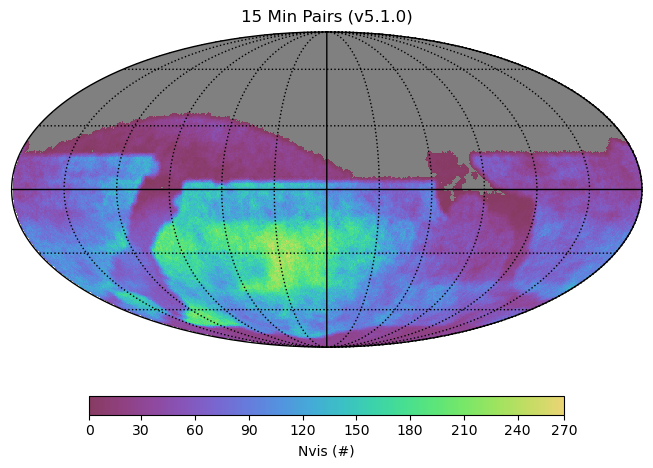

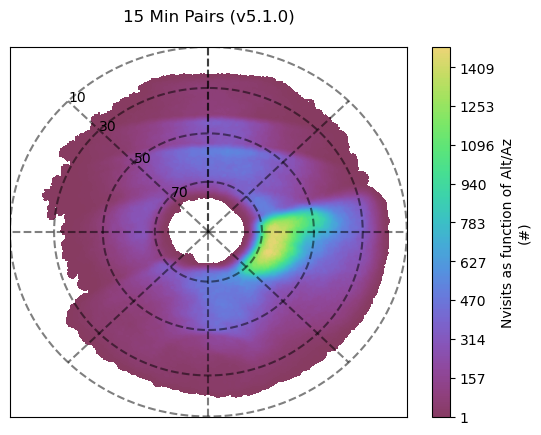

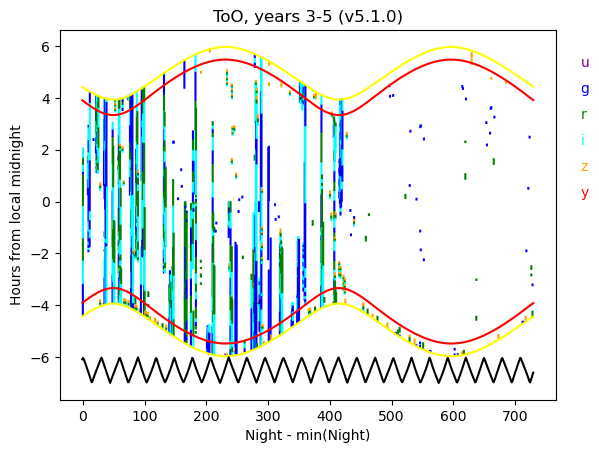

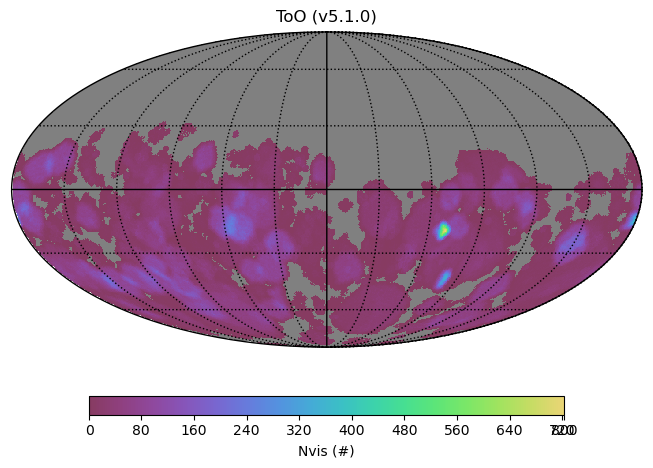

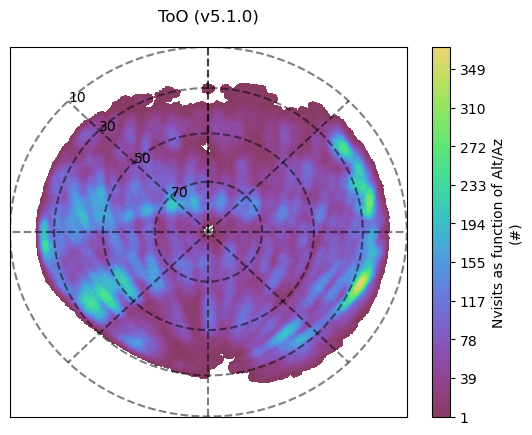

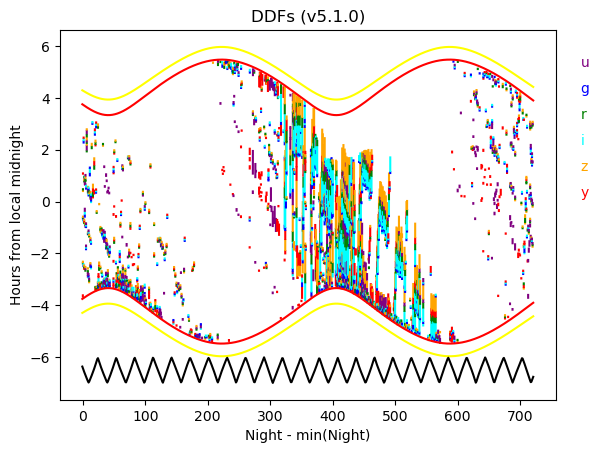

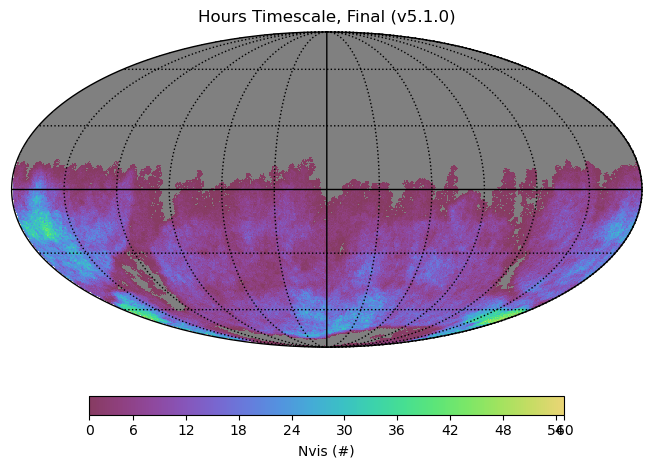

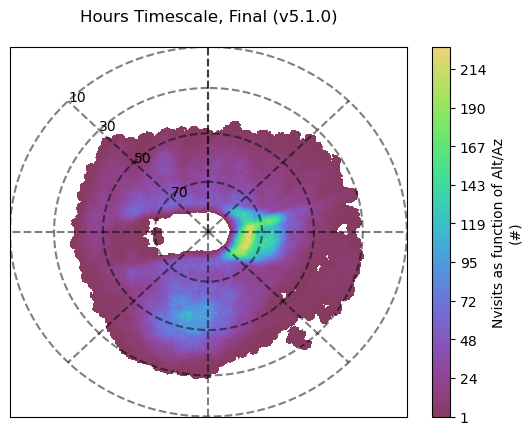

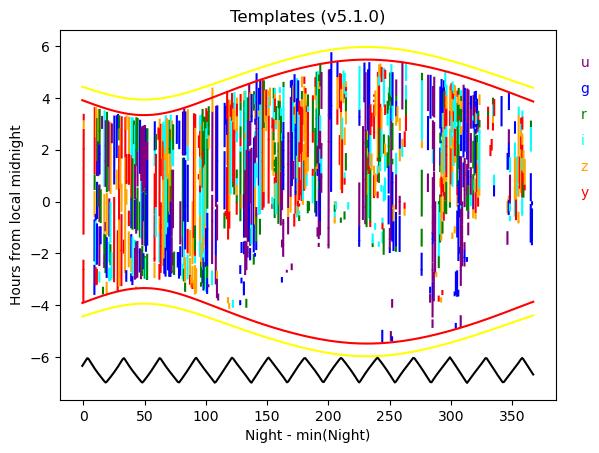

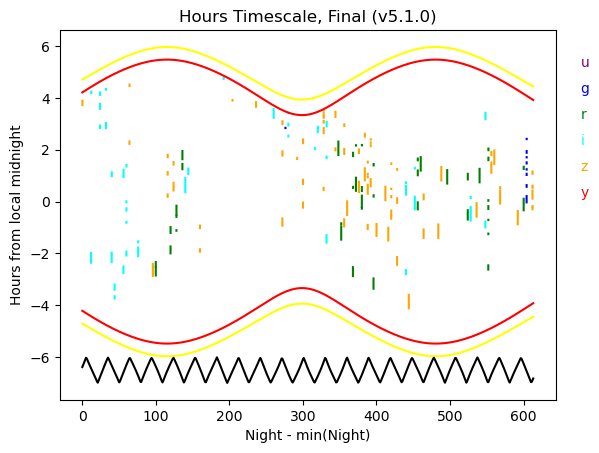

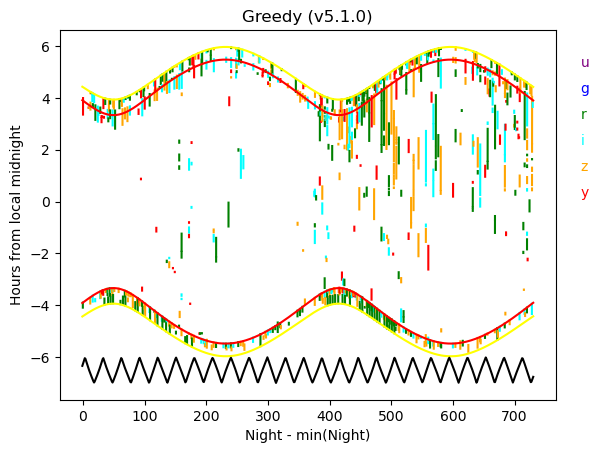

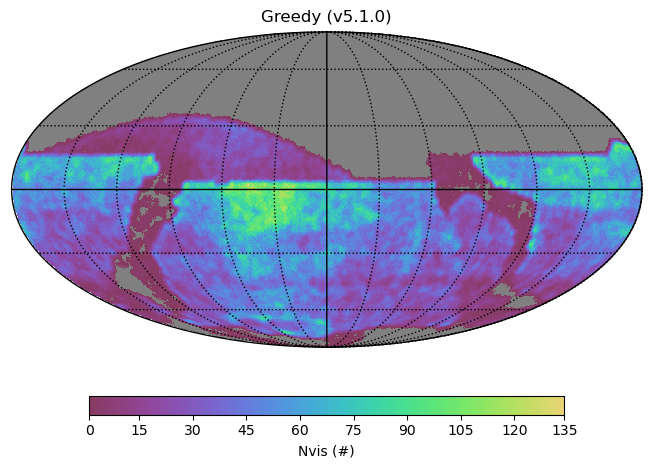

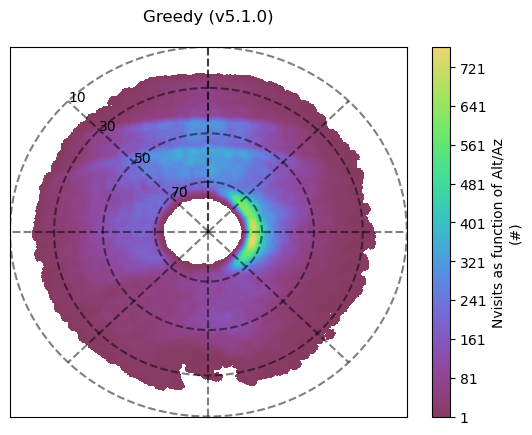

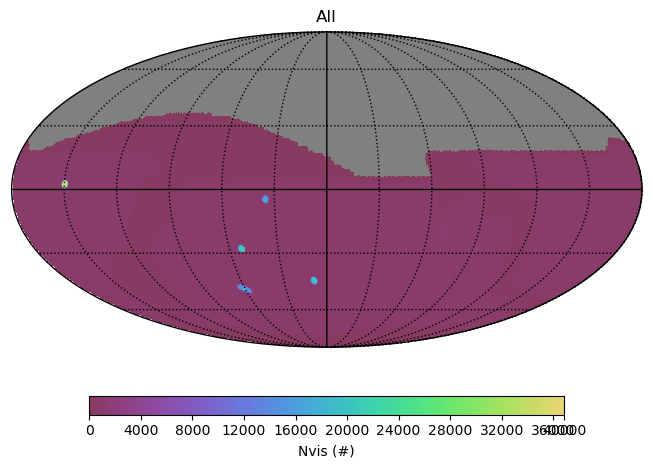

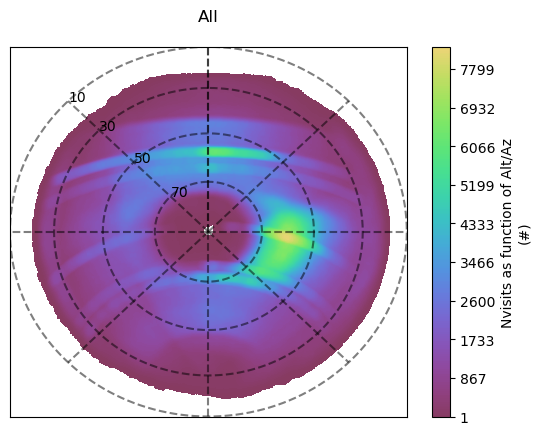

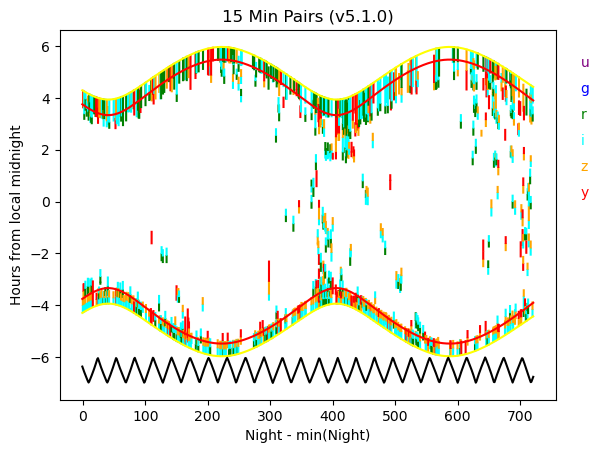

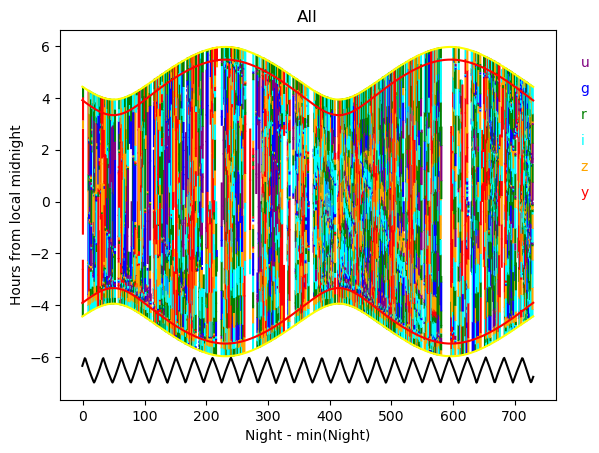

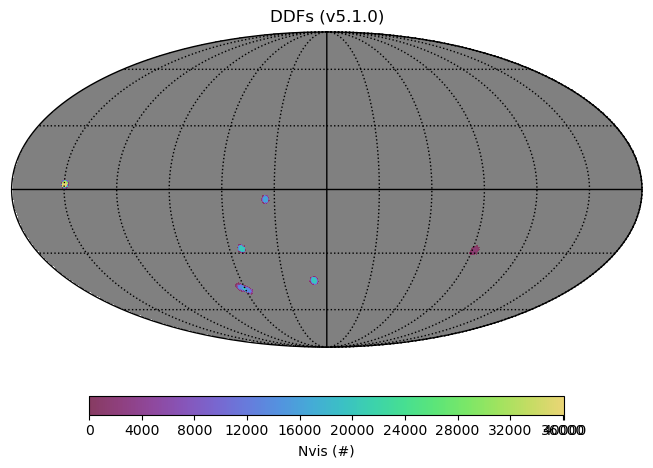

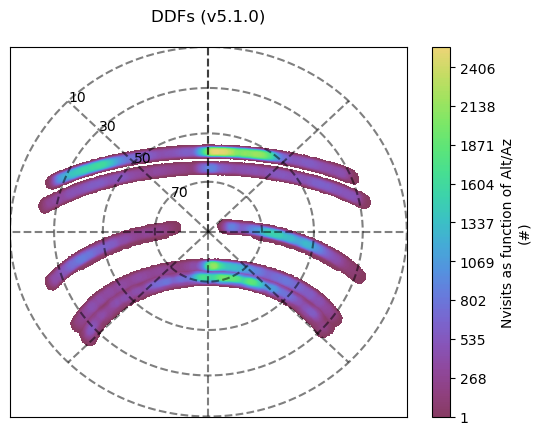

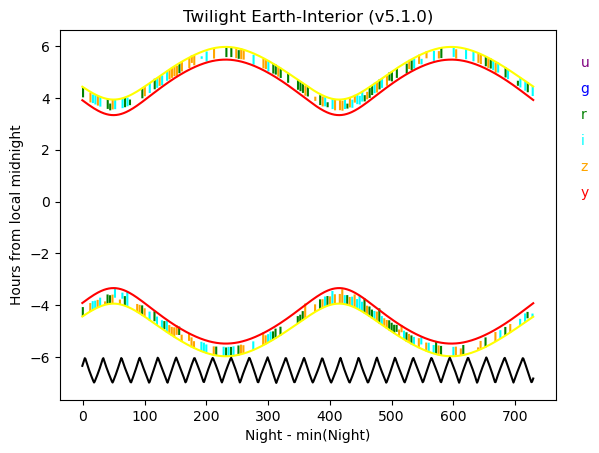

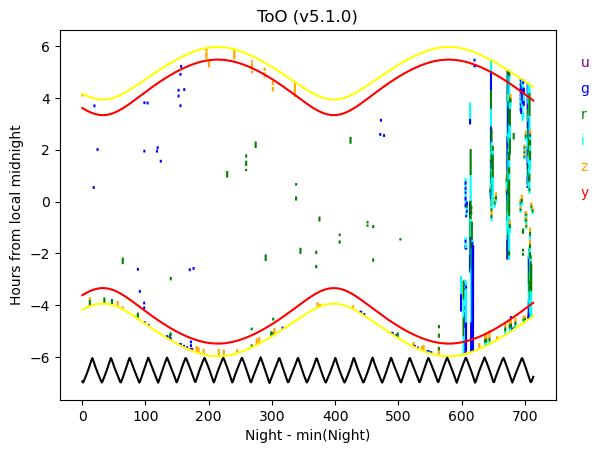

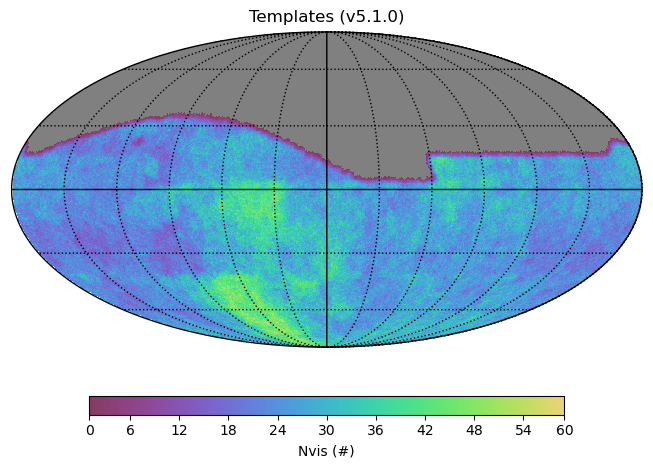

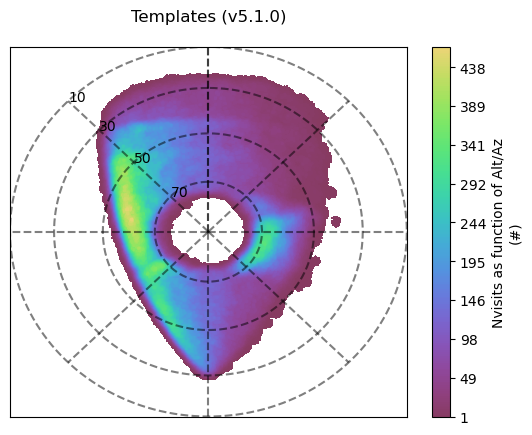

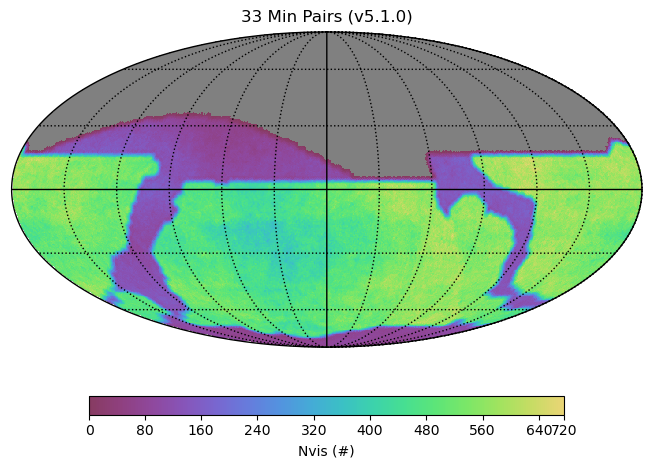

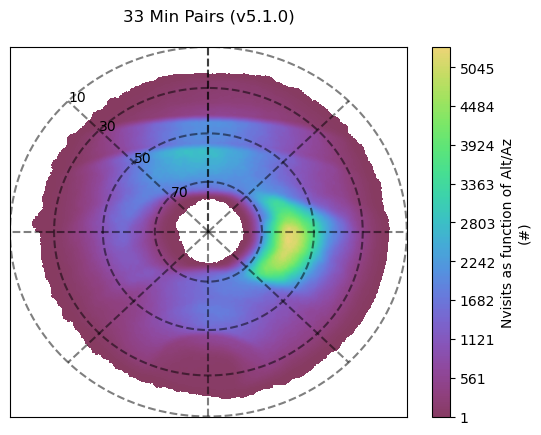

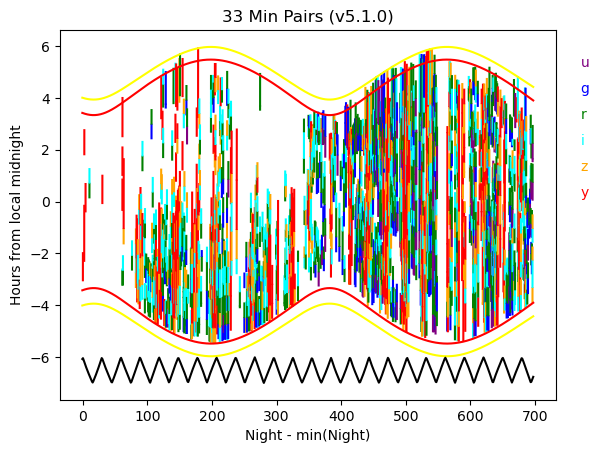

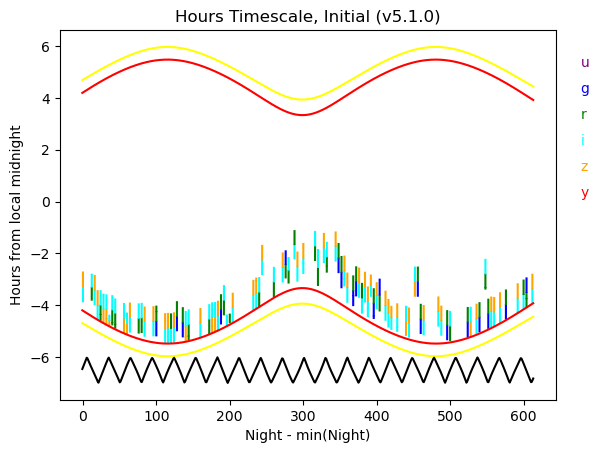

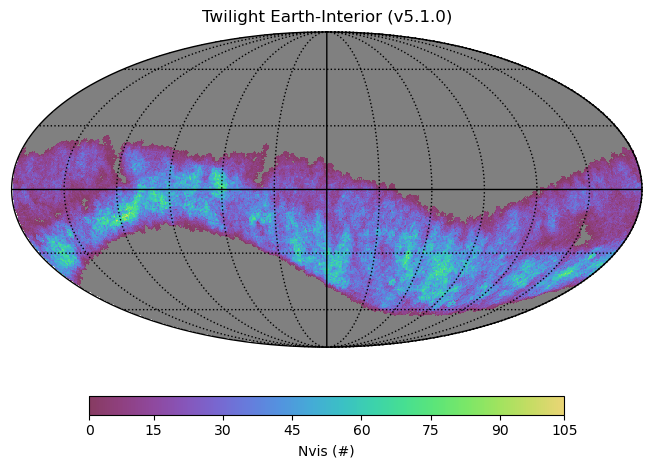

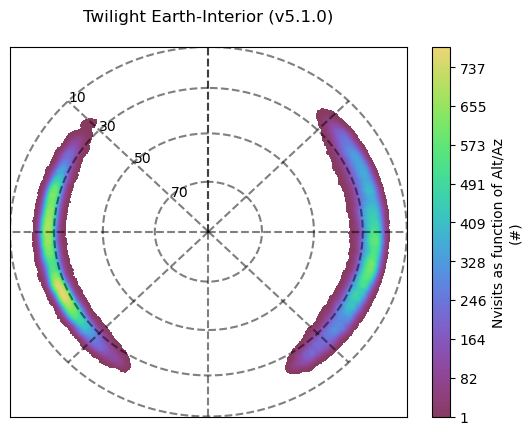

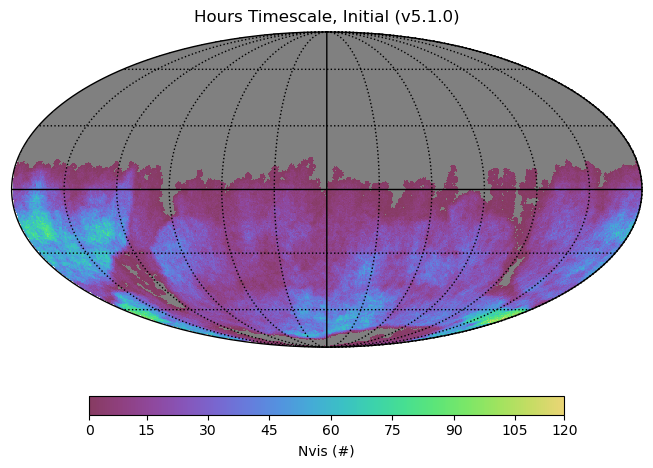

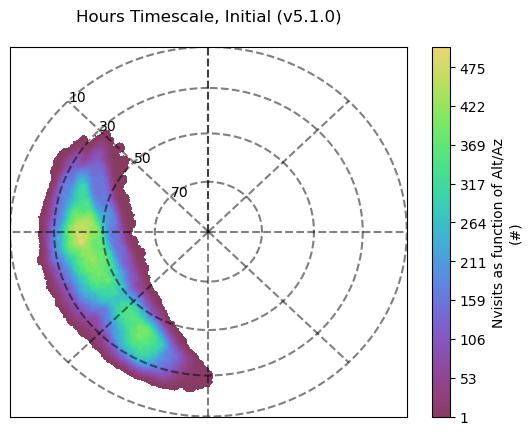

In [5]:
bd = maf.metricBundles.make_bundles_dict_from_list(bundle_list)
bg = maf.metricBundles.MetricBundleGroup(bd, baseline_file, out_dir=out_dir, results_db=results_db, save_early=False)
bg.run_all()
bg.plot_all(closefigs=False)


In [11]:
notes = {"'DD:%'": {'title': "DDFs" + v}, "'pair_33%'": {'title': "33 Min Pairs" + v},
         "'templates%'": {'title': "Templates" + v},
         "'pair_15%'": {"title": "15 Min Pairs" + v}, "'greedy%'": {"title": "Greedy" + v},
         "'ToO%'": {"title": 'ToO' + v}, "'twilight%'": {"title": "Twilight Earth-Interior" + v},
         "'blob_long%'": {"title": "Hours Timescale, Initial" + v}, "'long%'": {"title": "Hours Timescale, Final" + v},
        "": {"title": "All"}}


bundle_list = []
for note in notes:
    # col here could be anything
    metric = maf.metrics.SumMetric(col=['visitExposureTime'])
    sql = 'scheduler_note like %s' % note
    if note == "":
        sql = ""
    slicer = maf.slicers.UniSlicer()
    bundle_list.append(maf.MetricBundle(metric, slicer, sql, run_name=name))
bd = maf.metricBundles.make_bundles_dict_from_list(bundle_list)
bg = maf.metricBundles.MetricBundleGroup(bd, baseline_file, out_dir=out_dir, results_db=results_db, save_early=False)
bg.run_all()
bg.plot_all(closefigs=False)


In [12]:
for key in bd:
    print(key, bd[key].metric_values/bd["baseline_v5_1_0_10yrs_Sum_visitExposureTime_UNIS"].metric_values)

baseline_v5_1_0_10yrs_Sum_visitExposureTime_scheduler_note_like_DD_UNIS [0.06546898835424246]
baseline_v5_1_0_10yrs_Sum_visitExposureTime_scheduler_note_like_pair_33_UNIS [0.625615004154712]
baseline_v5_1_0_10yrs_Sum_visitExposureTime_scheduler_note_like_templates_UNIS [0.040646512466230175]
baseline_v5_1_0_10yrs_Sum_visitExposureTime_scheduler_note_like_pair_15_UNIS [0.1215075932034729]
baseline_v5_1_0_10yrs_Sum_visitExposureTime_scheduler_note_like_greedy_UNIS [0.053825348652898924]
baseline_v5_1_0_10yrs_Sum_visitExposureTime_scheduler_note_like_ToO_UNIS [0.043396012587878695]
baseline_v5_1_0_10yrs_Sum_visitExposureTime_scheduler_note_like_twilight_UNIS [0.012520028135767802]
baseline_v5_1_0_10yrs_Sum_visitExposureTime_scheduler_note_like_blob_long_UNIS [0.02639770436134815]
baseline_v5_1_0_10yrs_Sum_visitExposureTime_scheduler_note_like_long_UNIS [0.010622808083448829]
baseline_v5_1_0_10yrs_Sum_visitExposureTime_UNIS [1.0]
